In [1]:
# Libraries
#!pip install scipy --upgrade -i https://pypi.tuna.tsinghua.edu.cn/simple
#!pip install scipy -i https://mirrors.aliyun.com/pypi/simple/

import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

# Loading Mineral (Co) Network

In [2]:
# data from diff mineral
Miner_TN_df=pd.read_csv('cobalt94-23.txt', header=None, sep="\s+")


Miner_TN_df.columns=(['t','i','j'])

In [3]:
ordered_IDs = pd.read_csv('ID -cobalt94-23.txt', header=None, sep="\s+")


In [4]:
# tranform data in series of nx graphs

iis=np.unique(Miner_TN_df['i'])
jjs=np.unique(Miner_TN_df['j'])
nodes=np.union1d(iis,jjs)
x=np.unique(Miner_TN_df['t'])
Orelines_TN=[]
print(len(x))
for t in range(len(x)):
    fr=Miner_TN_df[Miner_TN_df['t']==x[t]][['i','j']]
    #gu=nx.from_pandas_edgelist(fr,'i','j')
    gu = nx.from_pandas_edgelist(fr, 'i', 'j', create_using=nx.DiGraph())  # Create a directed graph
    g = nx.DiGraph()
    #g=nx.Graph()
    g.add_nodes_from(nodes)
    g.add_edges_from(gu.edges)
    g.remove_edges_from(nx.selfloop_edges(g))
    Orelines_TN.append(g)
print(g)

30



In [5]:
# Aggregated network

N=len(nodes)
AL_AGG=nx.DiGraph()
al_agg=np.zeros((N,N))
for go in Orelines_TN:
    
    AL_AGG=nx.compose(AL_AGG,go)
    al_agg=al_agg+nx.to_numpy_matrix(go)
print(al_agg)
print(AL_AGG)

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 5. ... 0. 0. 0.]
 [3. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]



# Statistical properties of aggregated network

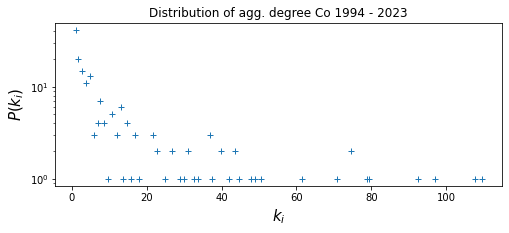

In [6]:
# Aggregate degree 

agg_k=[fr[1] for fr in list(AL_AGG.degree()) ]

x,y=np.histogram(agg_k,bins=200)

fig=plt.figure(figsize=(8,3))
plt.semilogy(y[:-1],x,'+')
plt.title('Distribution of agg. degree Co 1994 - 2023')
plt.xlabel('$k_i$',fontsize=15)
plt.ylabel('$P(k_i)$',fontsize=15)
plt.show()

In [7]:
ordered_k=np.sort(agg_k)
ordered_k[-100:]

array([  4,   4,   4,   4,   4,   4,   4,   5,   5,   5,   5,   5,   5,
         5,   5,   5,   5,   5,   5,   5,   6,   6,   6,   7,   7,   7,
         7,   8,   8,   8,   8,   8,   8,   8,   9,   9,   9,   9,  10,
        11,  11,  11,  11,  11,  12,  12,  12,  13,  13,  13,  13,  13,
        13,  14,  15,  15,  15,  15,  16,  17,  17,  17,  18,  22,  22,
        22,  23,  23,  25,  27,  27,  29,  30,  31,  31,  33,  34,  37,
        37,  37,  38,  40,  40,  42,  44,  44,  45,  48,  49,  51,  62,
        71,  75,  75,  79,  80,  93,  97, 108, 110])

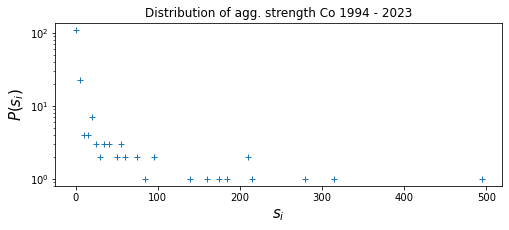

In [8]:
# Aggregate strength 


s=np.sum(al_agg,axis=1)

x,y=np.histogram(s,bins=100)

fig=plt.figure(figsize=(8,3))
plt.semilogy(y[:-1],x,'+')
plt.title('Distribution of agg. strength Co 1994 - 2023')
plt.xlabel('$s_i$',fontsize=15)
plt.ylabel('$P(s_i)$',fontsize=15)
plt.show()

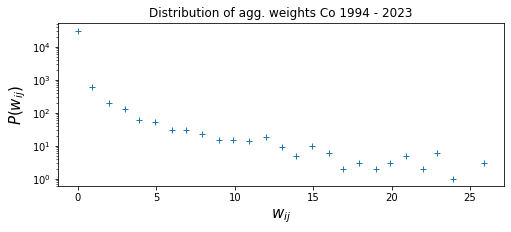

In [9]:
# Aggregate weights 


#w=np.array([al_agg[i,j] for i in range(N) for j in np.arange(i+1,N,1)])
w = np.array([al_agg[i, j] for i in range(N) for j in range(N) if i != j])

x,y=np.histogram(w,bins=200)
#x,y=np.histogram(w,bins=10)

fig=plt.figure(figsize=(8,3))
plt.semilogy(y[:-1],x,'+')
plt.title('Distribution of agg. weights Co 1994 - 2023')
plt.xlabel('$w_{ij}$',fontsize=15)
plt.ylabel('$P(w_{ij})$',fontsize=15)
plt.show()

# Temporal Rich Club

In [10]:
# Function of the rich club

def temporal_RC(Gt,AggG,k,delta,N,T,nodes):
    x=np.array([d[1] for d in AggG.degree()]) 
    # Filter nodes with a degree greater than k
    set_k=set(nodes[np.where(x>k)[0]])
    vec_k=nodes[np.where(x>k)[0]]
    size_Sk=len(vec_k)
    #Initialize the result array to determine whether the filtered nodes meet the conditions
    M_s=np.zeros(T-delta)
    if size_Sk>3:
        for t in range(T-delta):
            g=Gt[t] #A graph of each time step
            neighs=[[] for h in range(size_Sk)]
            for node in range(size_Sk):
                deh=set(nx.neighbors(Gt[t],vec_k[node]))
                neighs[node]=np.array(list(set_k & deh))
            # Calculate the intersection of the neighbor sets within the time interval delta            
            for D in range(delta):  
                for n in range(size_Sk):
                    doh=set(nx.neighbors(Gt[t+D],vec_k[n]))
                    neighs[n]=np.array(list(set(neighs[n]) & doh))
            #Calculate the intersection size and update M_s
            eps=[len(x) for x in neighs]
            M_s[t]=np.sum(eps)/float(size_Sk*(size_Sk-1))
      
        return np.max(M_s),M_s,size_Sk
    else:
        return 0,M_s,size_Sk
        print(size_Sk)

# $k-\Delta$ diagram

In [11]:

deltas=np.arange(0,30,1) 
ks=np.arange(1,90,1)
RC_mat=np.zeros((len(deltas),len(ks)))
for delta in range(len(deltas)):
    print(delta)
    for k in range(len(ks)):
        RC_mat[delta,k]=temporal_RC(Orelines_TN,AL_AGG,ks[k],deltas[delta],np.shape(Orelines_TN)[1],np.shape(Orelines_TN)[0],nodes)[0]
    

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29


In [12]:
# Size of S_k as a function of k

agg_k=[fr[1] for fr in list(AL_AGG.degree()) ]
aggs=np.zeros(90)
for ki in range(90):
    aggs[ki]=len(np.where(np.array(agg_k)>ki+1)[0]) # Traverse and calculate the number of nodes that meet the conditions


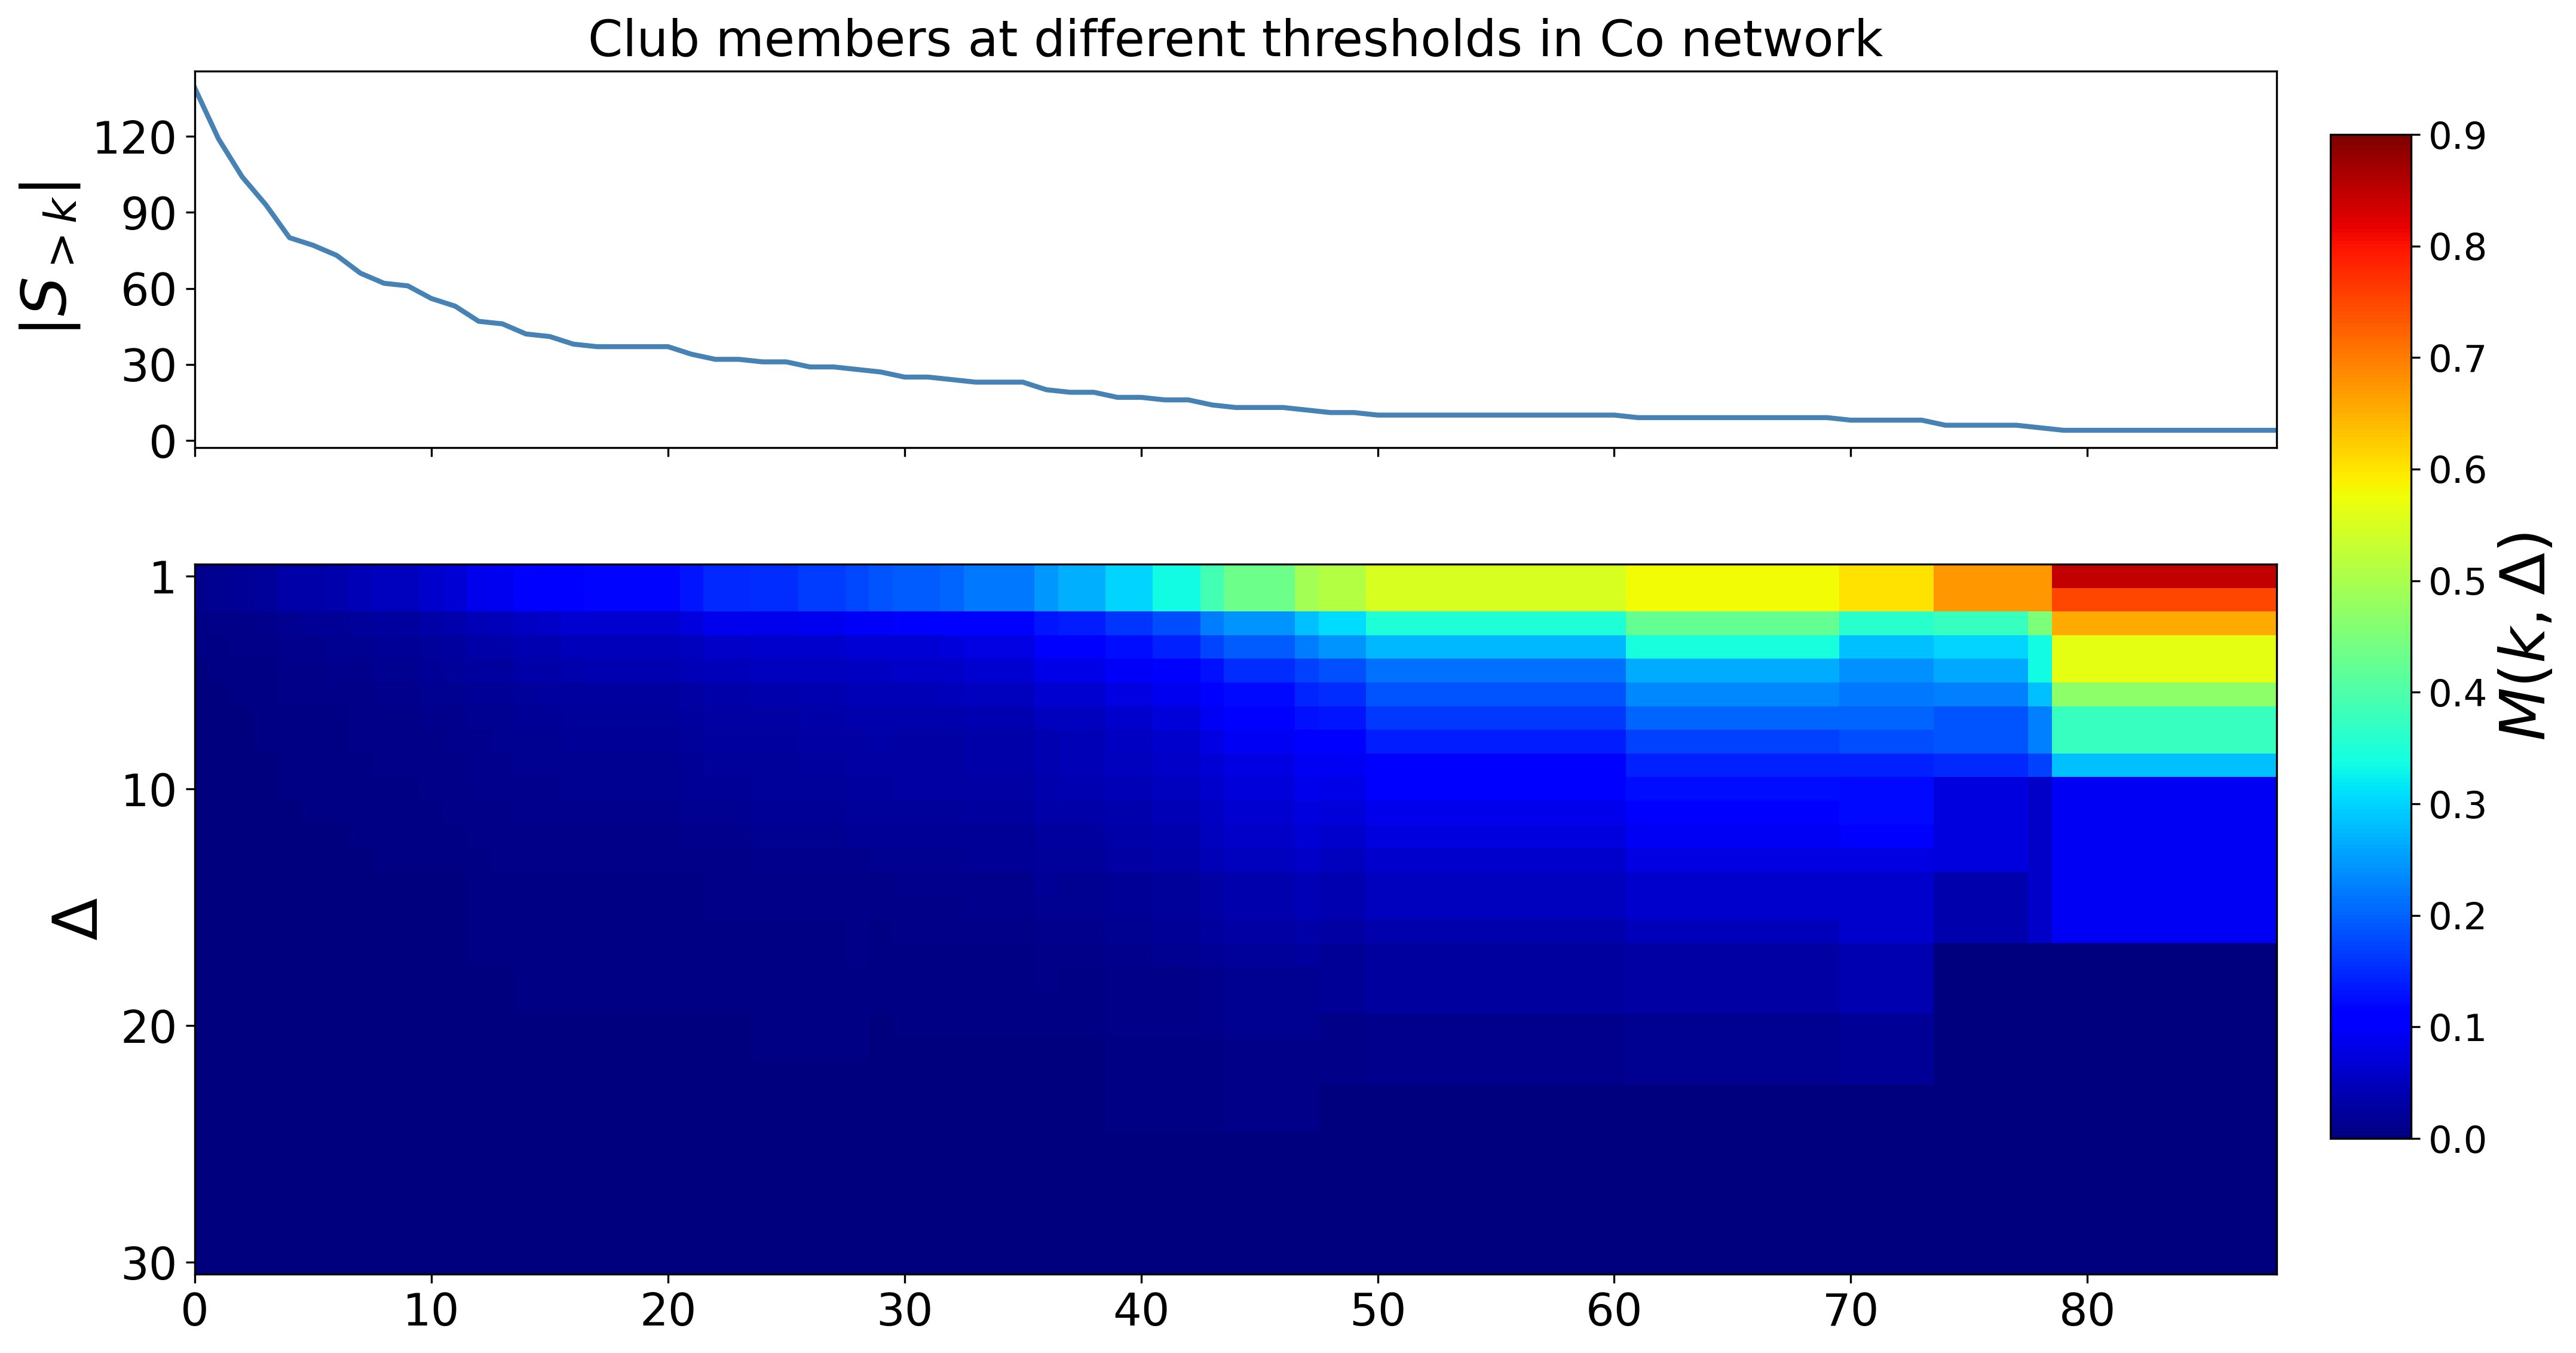

In [13]:
import matplotlib.pyplot as plt
import numpy as np

aggs = np.asarray(aggs)
RC_mat = np.asarray(RC_mat)

ns = np.arange(0, max(aggs), 30, dtype=int)

# Horizontal axis scale position: Automatically generated based on the actual length of the data, with each 10 grids
xlen_img = RC_mat.shape[1]         
xlen_line = len(aggs)               
xlen = max(xlen_img, xlen_line)     

xtick_pos = np.arange(0, xlen, 10)
xtick_labels = [str(p) if p <= 80 else '' for p in xtick_pos]  # Only mark up to 80

# Canvas
fig, (a2, a0) = plt.subplots(
    2, 1, gridspec_kw={'height_ratios': [0.9, 2]},
    figsize=(15, 8), sharex=True, dpi=300
)

# Line graph
a2.plot(np.arange(0, len(aggs), 1), aggs, color='#4682B4', linewidth=2)
a2.set_xticks(xtick_pos)
a2.set_xticklabels(xtick_labels, fontsize=18)
a2.set_xlim(0, xlen-1)                     
a2.set_ylabel(r'$|S_{>k}|$', fontsize=25)
a2.set_yticks(ns)
a2.set_yticklabels(ns, fontsize=18)
a2.set_title(r"Club members at different thresholds in Co network", fontsize=20)


z_1 = a0.imshow(RC_mat, cmap='jet', vmax=0.8, aspect=1, origin='upper')
a0.set_xticks(xtick_pos)
a0.set_xticklabels(xtick_labels, fontsize=18)
a0.set_xlim(0, xlen_img-1)                 

# Vertical axis label
y_tick_positions = [0, 9, 19, 29]
y_tick_labels    = [1, 10, 20, 30]
a0.set_yticks(y_tick_positions)
a0.set_yticklabels(y_tick_labels, fontsize=18)
a0.set_ylabel(r'$\Delta$', fontsize=25)

plt.tight_layout()

# Color bar
fig.subplots_adjust(right=0.85)
cbar_ax = fig.add_axes([0.87, 0.2, 0.03, 0.7])
cbar1 = fig.colorbar(z_1, cax=cbar_ax)
cbar1.ax.tick_params(labelsize=15)
cbar1.set_label(label=r'$M(k,\Delta)$', size=25)

delta_value = 10
row_idx = delta_value - 1
if 0 <= row_idx < RC_mat.shape[0]:
    color_values = RC_mat[row_idx, :]
plt.show()
